In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("antobenedetti/animals")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'animals' dataset.
Path to dataset files: /kaggle/input/animals
Contents of base_path (/kaggle/input):
['animals']
Contents of path (/kaggle/input/animals):
['animals']


In [ ]:
import os

dataset_dir = os.path.join(path, 'animals')
sub_folders = ['train', 'val', 'inf']

for folder in sub_folders:
    folder_path = os.path.join(dataset_dir, folder)
    if os.path.exists(folder_path):
        animal_classes = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        print(f"Folder '{folder}' contains {len(animal_classes)} animal classes.")
        print(f"Example classes: {animal_classes[:5]}\n")

Folder 'train' contains 5 animal classes.
Example classes: ['horse', 'lion', 'dog', 'elephant', 'cat']

Folder 'val' contains 5 animal classes.
Example classes: ['horse', 'lion', 'dog', 'elephant', 'cat']

Folder 'inf' contains 0 animal classes.
Example classes: []



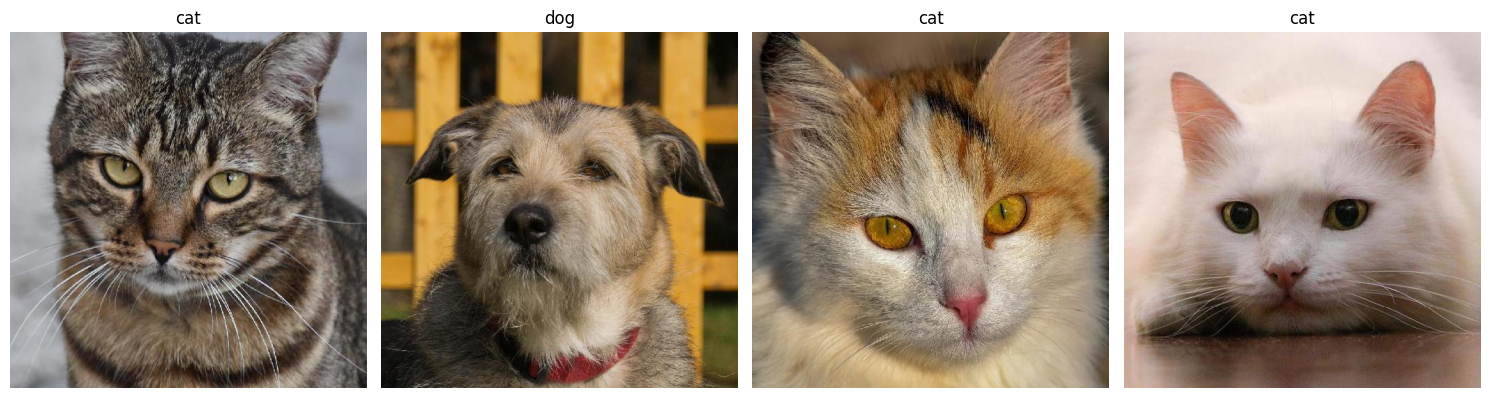

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

plt.figure(figsize=(15, 10))

train_dir = os.path.join(dataset_dir, 'train')
animal_types = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for i in range(4):
    selected_animal = random.choice(animal_types)
    animal_folder = os.path.join(train_dir, selected_animal)
    images = [f for f in os.listdir(animal_folder) if os.path.isfile(os.path.join(animal_folder, f))]

    if images:
        random_img = random.choice(images)
        img_path = os.path.join(animal_folder, random_img)
        img = mpimg.imread(img_path)
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.title(selected_animal)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")

Num GPUs Available:  1
Default GPU Device: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Set parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Prepare Generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build MobileNetV2 Model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(train_generator.class_indices), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Start Training
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Found 13474 images belonging to 5 classes.
Found 1497 images belonging to 5 classes.
Starting training...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 217s 494ms/step - accuracy: 0.8836 - loss: 0.3225 - val_accuracy: 0.9265 - val_loss: 0.2015
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 198s 468ms/step - accuracy: 0.9228 - loss: 0.2039 - val_accuracy: 0.9112 - val_loss: 0.2251
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 195s 463ms/step - accuracy: 0.9285 - loss: 0.1865 - val_accuracy: 0.9252 - val_loss: 0.1905
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 196s 464ms/step - accuracy: 0.9337 - loss: 0.1749 - val_accuracy: 0.9345 - val_loss: 0.1769
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 199s 471ms/step - accuracy: 0.9367 - loss: 0.1728 - val_accuracy: 0.9292 - val_loss: 0.1792
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 190s 449ms/step - accuracy: 0.9360 - loss: 0.1679 - val_accuracy: 0.9379 - val_loss: 0.1614
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 192s 454ms/step - accuracy: 0.9359 - loss: 0.1660 - val_accura

In [ ]:
# Training Summary
print("Training Summary:")
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Display class mapping
print("\nClass Indices:", train_generator.class_indices)

Training Summary:
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9312 - loss: 0.1826
Validation Loss: 0.1826
Validation Accuracy: 0.9312

Class Indices: {'cat': 0, 'dog': 1, 'elephant': 2, 'horse': 3, 'lion': 4}


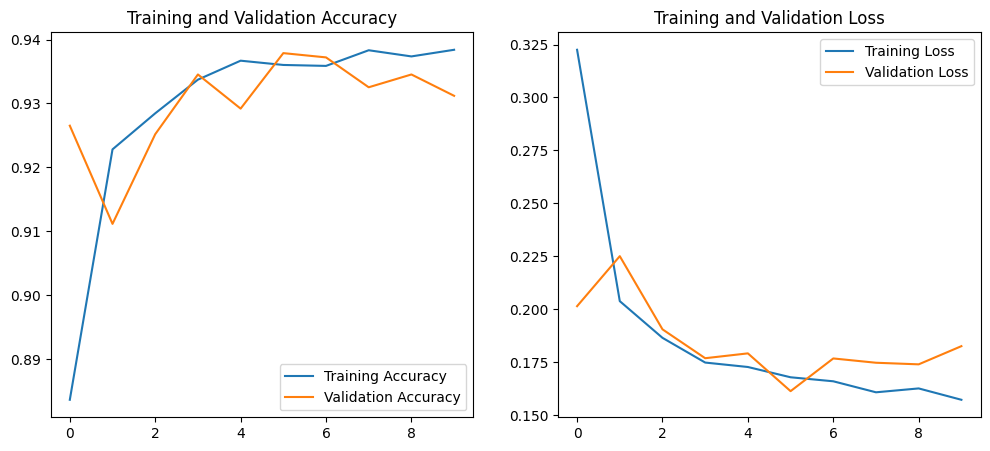

In [ ]:
# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()